# Rain Forecasting with Artificial Neural Network

We'll try to predict rain with ANN.
Let's start !

# What is an artificial neural network?
Artificial neural networks are one of the main tools used in machine learning. As the “neural” part of their name suggests, they are brain-inspired systems which are intended to replicate the way that we humans learn. Neural networks consist of input and output layers, as well as (in most cases) a hidden layer consisting of units that transform the input into something that the output layer can use. They are excellent tools for finding patterns which are far too complex or numerous for a human programmer to extract and teach the machine to recognize.

While neural networks (also called “perceptrons”) have been around since the 1940s, it is only in the last several decades where they have become a major part of artificial intelligence. This is due to the arrival of a technique called “backpropagation,” which allows networks to adjust their hidden layers of neurons in situations where the outcome doesn’t match what the creator is hoping for — like a network designed to recognize dogs, which misidentifies a cat, for example.

Another important advance has been the arrival of deep learning neural networks, in which different layers of a multilayer network extract different features until it can recognize what it is looking for.

![](http://icdn5.digitaltrends.com/image/artificial_neural_network_1-791x388.jpg)

In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Any results you write to the current directory are saved as output.

In [14]:
df = pd.read_csv('seattleWeather_1948-2017.csv')

In [15]:
df.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


# Data Analysis

Checking for *null* values

In [16]:
for column in df:
    print(column)
    print(df[column].isnull().sum().sum())

DATE
0
PRCP
3
TMAX
0
TMIN
0
RAIN
3


There are very few *null* values so we can drop them.

In [17]:
df.dropna(inplace=True)

In [18]:
#plt.figure(figsize=(14,6))
#df['TMAX'].plot()
#plt.xlabel('Days')
#plt.ylabel('Temperature [F]')

In [19]:
#plt.figure(figsize=(12, 7))
#sns.boxplot(x='RAIN',y='TMAX',data=df,palette='winter')

I will make RAIN column numeric before I start with predictions but for analysis it is nicer to see the label names.

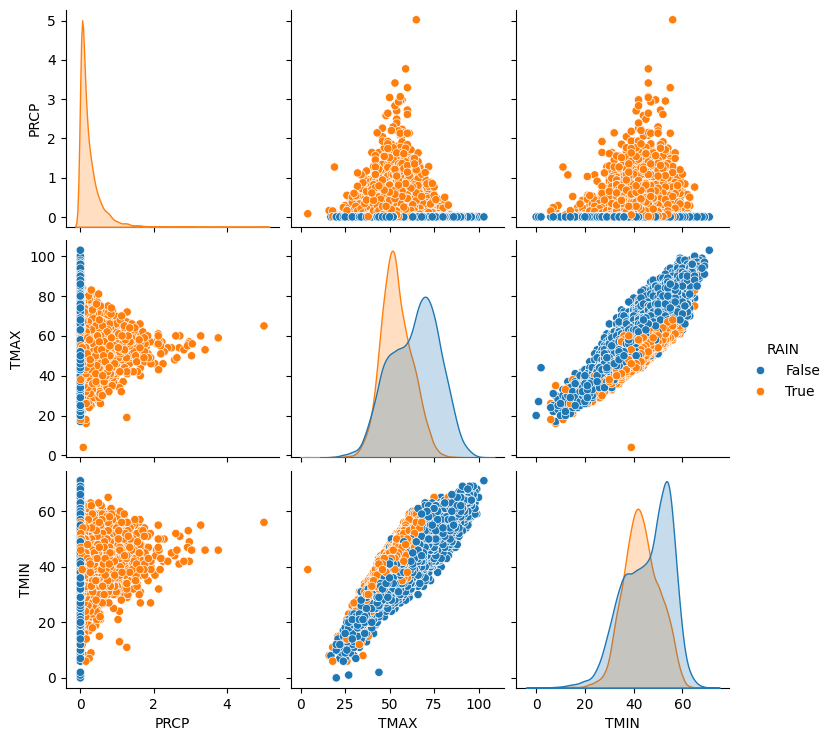

In [20]:
sns.pairplot(df, hue='RAIN')

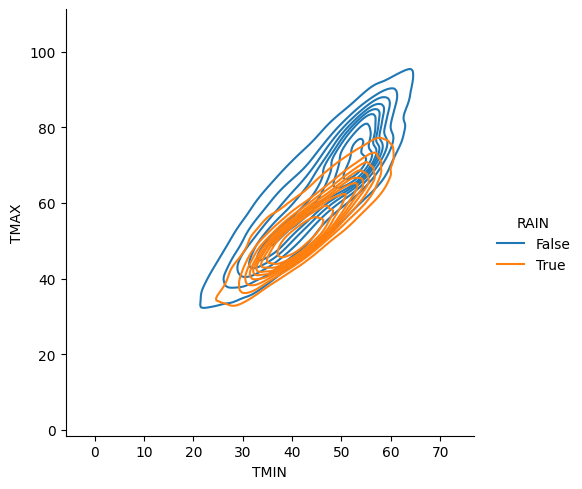

In [21]:
sns.displot(data=df, x='TMIN', y='TMAX', hue='RAIN', kind='kde')

It seems an easy classification problem when you see it. But uncertainty of **not raining** is tricky as you can see on the above.

In [22]:
#df['PRCP'].plot(kind='hist',bins=30,color='orange',figsize= (16,7))

We are going to convert rain column to numeric for ann

In [23]:
rain = pd.get_dummies(df['RAIN'], drop_first=True)
df = df.drop('RAIN', axis=1)
df = pd.concat([df, rain], axis=1)
print(df.shape)
df.head()

(25548, 5)


,DATE,PRCP,TMAX,TMIN,True
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import metrics

In [25]:
df.columns = ['DATE', 'PRCP', 'TMAX', 'TMIN', 'RAIN']
df.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [26]:
#df.info()

In [27]:
x = df[['PRCP', 'TMAX', 'TMIN']]
y = df['RAIN']

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [29]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#xtrain = scaler.fit_transform(xtrain)
#xtest = scaler.transform(xtest)

We are going to create ann model.

In [30]:
import keras 
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Dropout

2025-10-23 14:24:11.539025: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-23 14:24:11.860779: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-23 14:24:13.744866: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [31]:
model = Sequential([
    Dense(32, activation='relu', input_dim=3),
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
    ])
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
model.summary()

/home/federico/unibo/machLearnComplex/ML_complex/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1761222254.035666    6640 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1761222254.038721    6640 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673 (2.63 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(x_train, y_train, batch_size=10, epochs=20, verbose=1)

Epoch 1/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7096 - loss: 0.1925
Epoch 2/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7666 - loss: 0.1595
Epoch 3/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7992 - loss: 0.1371
Epoch 4/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.8213 - loss: 0.1217
Epoch 5/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8358 - loss: 0.1121
Epoch 6/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8491 - loss: 0.1061  
Epoch 7/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.8576 - loss: 0.1004
Epoch 8/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8638 - loss: 0.0954  
Epoch 9/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8743 - loss: 0.0899  
Epoch 10/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8797 - loss: 0.0869
Epoch 11/20
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8776 - loss: 0.0861
Epoch 12/20
1917/191

In [33]:
#print(history.history.keys())

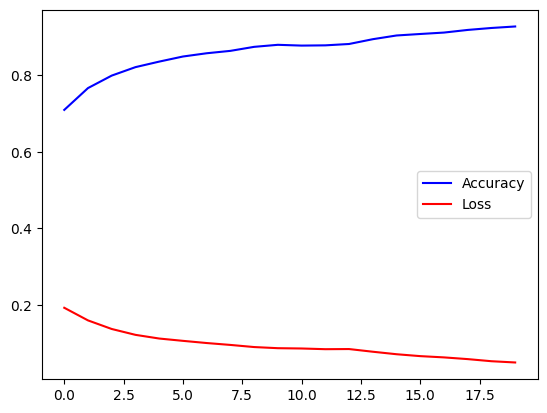

In [34]:
plt.plot(history.history['accuracy'], label='Accuracy', color='blue')
plt.plot(history.history['loss'], label='Loss', color='red')
plt.legend()

In [35]:
prediction_nn = model.predict(x_test)
prediction_nn = [1 if y>=0.5 else 0 for y in prediction_nn]
print(classification_report(y_test, prediction_nn))

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step
              precision    recall  f1-score   support

       False       0.90      1.00      0.95      3683
        True       1.00      0.85      0.92      2704

    accuracy                           0.94      6387
   macro avg       0.95      0.93      0.93      6387
weighted avg       0.94      0.94      0.94      6387



In [36]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, prediction_nn)
print(cm)

[[3683    0]
 [ 400 2304]]
